## House Price Prediction - Multivariate Analysis

**Story:** In this part, we will analyze the correlation between more than 2 variables while keeping the target variable (price) included. This will help us to get a better understanding and enhanced pricing analysis

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df = pd.read_csv(r"clean_data.csv")

In [14]:
df.head()

,area_sqft,rooms,build_year,location,street_type,furnishing,property_type,has_pool,price
0,2473.192784,4,1992,jaipur,residential lane,furnished,apartment,0,568486.0
1,2353.472711,4,2006,indore,corner plot,unfurnished,apartment,1,577214.0
2,2212.222005,3,2012,jaipur,highway facing,semi-furnished,duplex,0,581300.0
3,2823.886596,6,1993,lucknow,main road,unfurnished,villa,1,794614.0
4,1869.648721,5,2012,jaipur,corner plot,semi-furnished,apartment,0,493086.0


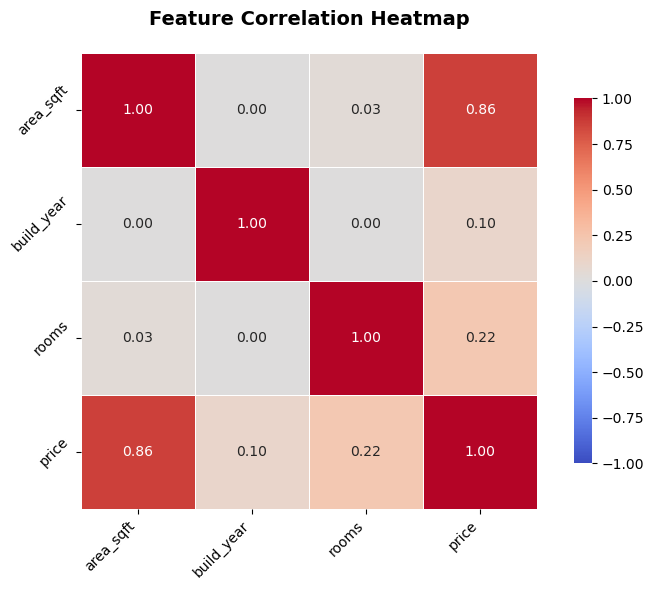

In [15]:
df1 = df[['area_sqft','build_year','rooms','price']]
corr = df1.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, 
            annot=True,             
            fmt=".2f",               
            cmap='coolwarm',         
            vmin=-1, vmax=1,         
            linewidths=0.5,         
            cbar_kws={"shrink": .8}, 
            square=True)              

plt.title('Feature Correlation Heatmap', pad=20, fontsize=14, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=45)

plt.tight_layout()
plt.show()

A strong positive linear correlation ($\rho = 0.86$) exists between area_sqft and price. This indicates a robust direct relationship, demonstrating that property prices scale predictably upward as square footage increases.

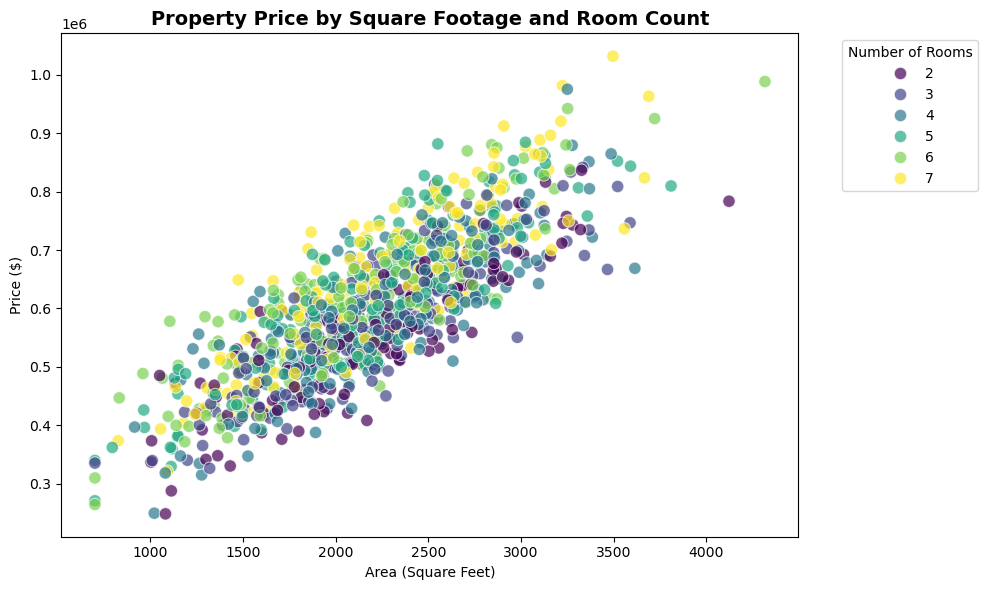

In [16]:
plt.figure(figsize=(10, 6))
df1 = df[df['area_sqft']<5000]
sns.scatterplot(
    data=df1, 
    x='area_sqft', 
    y='price', 
    hue='rooms', 
    palette='viridis',
    alpha=0.7,         
    s=80               
)

plt.title('Property Price by Square Footage and Room Count', fontsize=14, fontweight='bold')
plt.xlabel('Area (Square Feet)')
plt.ylabel('Price ($)')

plt.legend(title='Number of Rooms', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

The multivariate plot reveals several key structural trends regarding property configurations and their pricing dynamics:

* **2-Room Configurations (Budget-Friendly Utility):** Two-room properties exhibit a broad distribution across the entire square-footage spectrum. However, they consistently price lower than equivalent-sized properties with higher room counts, positioning them as a highly cost-effective, entry-level option.
* **3- to 4-Room Configurations (Market Standard):** Properties featuring three to four rooms represent the most concentrated segment of the market. They occupy a median pricing tier, establishing a balanced middle ground between two-room units and premium high-capacity homes of the same size.
* **7-Room Configurations (Premium Segment):** Seven-room properties maintain a solid market presence but command the highest price premium. For buyers without strict budget constraints, this configuration represents the luxury tier, maximizing spatial utility and room capacity.

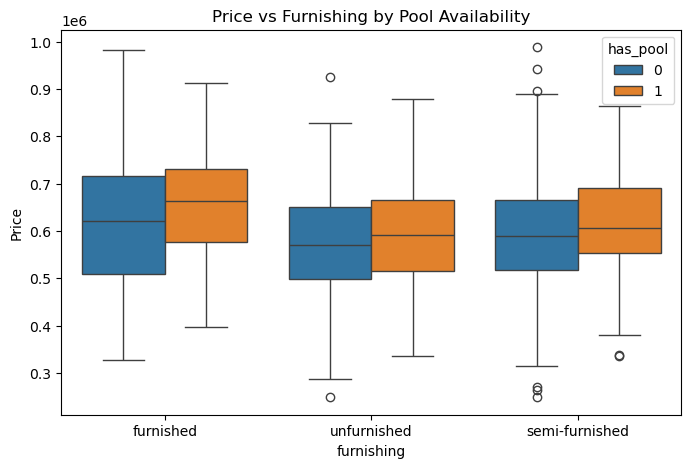

In [17]:
plt.figure(figsize=(8,5))
df1 = df[df['price']<1000000]
sns.boxplot(x='furnishing', y='price', hue='has_pool', data=df1)
plt.title('Price vs Furnishing by Pool Availability')
plt.ylabel('Price')
plt.legend(title='has_pool')

Few things to notice:

**Pools Increase the Price:** Across all three furnishing categories, the median line (the horizontal line inside the boxes) for the orange "pool" group is consistently higher than the blue "no pool" group. This means having a pool generally raises the price of the property, regardless of how furnished it is.

**Furnishing Increases the Price:** If you look at the general height of the boxes from left to right, "furnished" properties command the highest prices, followed by "semi-furnished," and "unfurnished" properties are generally the cheapest.

**Outliers Exist:** The small open circles above and below some of the boxes represent outliers—specific properties that are unusually expensive or unusually cheap compared to the rest of their category. (For example, there is a very expensive semi-furnished home without a pool hovering near the 1,000,000 mark).

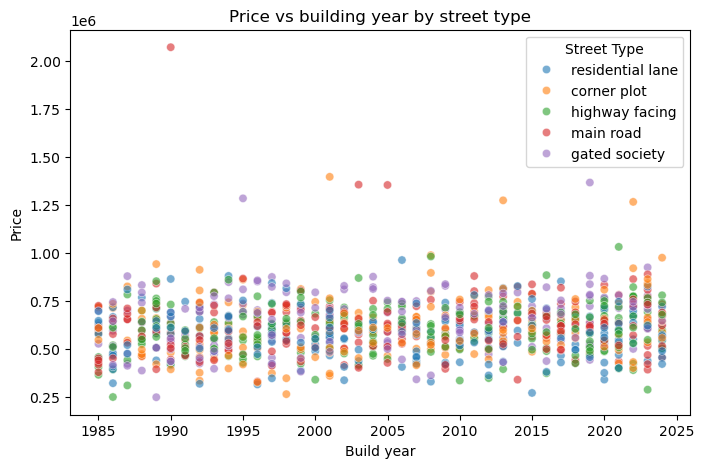

In [18]:
plt.figure(figsize=(8,5))
#df1=df[df['price']<1500000]
sns.scatterplot(
    x='build_year',
    y='price',
    hue='street_type',
    data=df,
    alpha=0.6
)
plt.title('Price vs building year by street type')
plt.xlabel('Build year')
plt.ylabel('Price')
plt.legend(title='Street Type')
plt.show()

**Key Takeaways:**

**A Dense Price Band:** The vast majority of properties, regardless of when they were built or where they are located, are tightly clustered in a price range between roughly 300,000 and 850,000.

**Age Doesn't Dictate Price Here:** There isn't a strong upward or downward slant to that main cluster of dots. This indicates that, in this specific dataset, a newer home isn't automatically much more expensive than an older home; prices remain relatively stable across the decades.

**Notable Outliers:** There are several exceptionally high-priced properties that break away from the main cluster. For example, the most expensive property on the chart is a red dot (main road) built around 1989, priced over 2 million. There are also a few high-priced corner plots (orange) and gated society homes (purple) scattered across different years.